In [1]:
# Paste this whole cell and run it on Kaggle
import os, time, socket
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.applications import DenseNet121, EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BASE_INPUT = "/kaggle/input/recyclable-waste-classification"  # change only if your top-level folder differs
IMG_SIZE = (224,224)
BATCH = 32

# --- 1) Auto-detect the folder that contains class subfolders ---
def find_class_dir(base):
    # look for first subfolder that contains many subfolders (classes)
    for root, dirs, files in os.walk(base):
        # candidate if this directory's immediate children are folders and those folders contain images
        if len(dirs) >= 2:
            # quick check that children contain image files
            ok = False
            for d in dirs:
                dpath = os.path.join(root, d)
                if any(fname.lower().endswith(('.jpg','.jpeg','.png')) for fname in os.listdir(dpath)[:50] if os.path.isdir(dpath) or True):
                    ok = True
                    break
            if ok:
                return root
    return base

DATA_DIR = find_class_dir(BASE_INPUT)
print("Using DATA_DIR =", DATA_DIR)
print("Top-level contents:", os.listdir(DATA_DIR)[:30])

# --- 2) Create generator and confirm class count ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    brightness_range=(0.75,1.25),
    horizontal_flip=True,
    fill_mode='nearest'
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=True
)

CLASS_INDICES = train_gen.class_indices
NUM_CLASSES = len(CLASS_INDICES)
print("Detected classes:", CLASS_INDICES)
if NUM_CLASSES <= 1:
    raise SystemExit("ERROR: Only 1 class detected. Check DATA_DIR and ensure images are organized into per-class subfolders (e.g., cardboard/, plastic/, metal/, ...).")

STEPS_PER_EPOCH = max(1, train_gen.samples // BATCH)
print("Samples:", train_gen.samples, "Num classes:", NUM_CLASSES, "Steps/epoch:", STEPS_PER_EPOCH)

# --- 3) Helper: test internet access (quick) ---
def has_internet(host="8.8.8.8", port=53, timeout=2):
    try:
        socket.create_connection((host, port), timeout=timeout)
        return True
    except:
        return False

print("Internet available:", has_internet())

# --- 4) Try to load DenseNet121 (with retries). Fallback to EfficientNetB3 or weights=None ---
def try_load_backbone(backbone_name="densenet"):
    # returns (base_model, used_weights_string)
    if backbone_name == "densenet":
        for attempt in range(3):
            try:
                print(f"Attempt {attempt+1}: Loading DenseNet121 imagenet weights...")
                base = DenseNet121(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0],IMG_SIZE[1],3), pooling='avg')
                print("DenseNet121 loaded with imagenet weights.")
                return base, 'imagenet'
            except Exception as e:
                print("DenseNet121 download failed:", str(e))
                time.sleep(2)
        print("DenseNet121 with imagenet failed after retries.")
        return None, None

    if backbone_name == "efficientnetb3":
        for attempt in range(3):
            try:
                print(f"Attempt {attempt+1}: Loading EfficientNetB3 imagenet weights...")
                base = EfficientNetB3(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0],IMG_SIZE[1],3), pooling='avg')
                print("EfficientNetB3 loaded with imagenet weights.")
                return base, 'imagenet'
            except Exception as e:
                print("EfficientNetB3 download failed:", str(e))
                time.sleep(2)
        print("EfficientNetB3 with imagenet failed after retries.")
        return None, None

# prefer DenseNet if internet works, else try EfficientNetB3, else use DenseNet w/o pretrained
base = None
weights_used = None

if has_internet():
    base, weights_used = try_load_backbone("densenet")
    if base is None:
        base, weights_used = try_load_backbone("efficientnetb3")

if base is None:
    print("No pretrained backbone available or downloads failing — creating DenseNet121 with weights=None (train from scratch).")
    base = DenseNet121(include_top=False, weights=None, input_shape=(IMG_SIZE[0],IMG_SIZE[1],3), pooling='avg')
    weights_used = 'none'

# Freeze base initially
base.trainable = False
print("Backbone ready. weights_used =", weights_used)
print("Backbone output shape:", base.output_shape)

# --- 5) Build classification head using detected NUM_CLASSES ---
inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base(inputs, training=False)
x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 6) Summary ---
print("\nMODEL SUMMARY:")
model.summary()


2025-11-26 13:23:02.679994: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764163382.949846      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764163383.026001      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,565,895 (28.86 MB)

 Trainable params: 528,391 (2.02 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [2]:
import os
BASE = "/kaggle/input/recyclable-waste-classification"  # change if needed
for root, dirs, files in os.walk(BASE):
    level = root.replace(BASE, '').count(os.sep)
    if level == 1:  # top level subfolders
        print("Folder:", root, "subfolders:", len(dirs))
    if level == 2:
        # print class counts
        cls = os.path.basename(root)
        imgs = [f for f in os.listdir(root) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f"Class {cls} -> {len(imgs)} images")


Folder: /kaggle/input/recyclable-waste-classification/Recycleable Waste - Dataset subfolders: 7
Class Metal -> 1200 images
Class Food,Organics,BIO - Wastes -> 851 images
Class Glass -> 921 images
Class Paper -> 1116 images
Class Cardboard -> 869 images
Class Textile Trash -> 352 images
Class Plastic -> 1444 images


In [3]:
import cv2, os
from tqdm import tqdm
SRC = "/kaggle/input/recyclable-waste-classification/Recycleable Waste - Dataset"  # adjust
OUT = "/kaggle/working/resized_data"
os.makedirs(OUT, exist_ok=True)

for cls in sorted(os.listdir(SRC)):
    p = os.path.join(SRC, cls)
    if not os.path.isdir(p): continue
    outp = os.path.join(OUT, cls)
    os.makedirs(outp, exist_ok=True)
    for imgf in tqdm(os.listdir(p), desc=cls):
        srcf = os.path.join(p, imgf)
        try:
            im = cv2.imread(srcf)
            if im is None: continue
            im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
            im = cv2.resize(im, (224,224))
            cv2.imwrite(os.path.join(outp, imgf), cv2.cvtColor(im, cv2.COLOR_RGB2BGR))
        except Exception as e:
            # skip corrupt images
            continue
print("Resizing done.")


Textile Trash: 100%|██████████| 352/352 [00:03<00:00, 90.53it/s]

Resizing done.


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG = (224,224)
BATCH = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    brightness_range=(0.75,1.25),
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.20
)

train_gen = datagen.flow_from_directory("/kaggle/working/resized_data", target_size=IMG, batch_size=BATCH, subset='training', class_mode='categorical', shuffle=True)
val_gen   = datagen.flow_from_directory("/kaggle/working/resized_data", target_size=IMG, batch_size=BATCH, subset='validation', class_mode='categorical', shuffle=False)

num_classes = train_gen.num_classes
print("Num classes:", num_classes)


Found 5405 images belonging to 7 classes.
Found 1348 images belonging to 7 classes.
Num classes: 7


In [5]:
import socket, time
def has_internet():
    try:
        socket.create_connection(("8.8.8.8",53), 2)
        return True
    except:
        return False

from tensorflow.keras.applications import DenseNet121, EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

if has_internet():
    try:
        backbone = DenseNet121(include_top=False, weights='imagenet', input_shape=(224,224,3), pooling='avg')
        print("Loaded DenseNet121 imagenet")
    except Exception as e:
        print("DenseNet imagenet failed:", e)
        try:
            backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=(224,224,3), pooling='avg')
            print("Loaded EfficientNetB3 imagenet")
        except Exception as e2:
            print("EfficientNetB3 failed:", e2)
            backbone = DenseNet121(include_top=False, weights=None, input_shape=(224,224,3), pooling='avg')
            print("Falling back to DenseNet w/o pretrained weights.")
else:
    print("No internet detected — using DenseNet without pretrained weights.")
    backbone = DenseNet121(include_top=False, weights=None, input_shape=(224,224,3), pooling='avg')

backbone.trainable = False

x = backbone.output
x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.4)(x)
out = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=backbone.input, outputs=out)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


No internet detected — using DenseNet without pretrained weights.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,565,895 (28.86 MB)

 Trainable params: 528,391 (2.02 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger
ckpt = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
rlp = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
es  = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
csv = CSVLogger('train_log.csv')

history1 = model.fit(train_gen, validation_data=val_gen, epochs=12, steps_per_epoch=max(1,train_gen.samples//BATCH), callbacks=[ckpt, rlp, es, csv])


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2066 - loss: 1.9813
Epoch 1: val_loss improved from inf to 1.93623, saving model to best_model.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 625s 4s/step - accuracy: 0.2066 - loss: 1.9812 - val_accuracy: 0.2136 - val_loss: 1.9362 - learning_rate: 1.0000e-04
Epoch 2/12
  1/168 ━━━━━━━━━━━━━━━━━━━━ 6:34 2s/step - accuracy: 0.1875 - loss: 1.8825

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 1.93623 to 1.93444, saving model to best_model.h5


...

168/168 ━━━━━━━━━━━━━━━━━━━━ 603s 3s/step - accuracy: 0.2100 - loss: 1.9095 - val_accuracy: 0.2136 - val_loss: 1.9087 - learning_rate: 1.0000e-04
Epoch 6/12
  1/168 ━━━━━━━━━━━━━━━━━━━━ 7:29 3s/step - accuracy: 0.1875 - loss: 1.9524
Epoch 6: val_loss improved from 1.90866 to 1.90832, saving model to best_model.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 118s 689ms/step - accuracy: 0.1875 - loss: 1.9524 - val_accuracy: 0.2136 - val_loss: 1.9083 - learning_rate: 1.0000e-04
Epoch 7/12
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2207 - loss: 1.8939
Epoch 7: val_loss improved from 1.90832 to 1.90509, saving model to best_model.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 610s 4s/step - accuracy: 0.2206 - loss: 1.8939 - val_accuracy: 0.2136 - val_loss: 1.9051 - learning_rate: 1.0000e-04
Epoch 8/12
  1/168 ━━━━━━━━━━━━━━━━━━━━ 7:18 3s/step - accuracy: 0.2500 - loss: 1.8037
Epoch 8: val_loss improved from 1.90509 to 1.90338, saving model to best_model.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 119s 697ms/step - accuracy: 0.2500 - loss: 1.8037 - val_accuracy: 0.2136 - val_loss: 1.9034 - learning_rate: 1.0000e-04
Epoch 9/12
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2091 - loss: 1.8964
Epoch 9: val_loss did not improve from 1.90338
168/168 ━━━━━━━━━━━━━━━━━━━━ 577s 3s/step - accuracy: 0.2091 - loss: 1.8964 - val_accuracy: 0.2136 - val_loss: 1.9057 - learning_rate: 1.0000e-04
Epoch 10/12
  1/168 ━━━━━━━━━━━━━━━━━━━━ 7:21 3s/step - accuracy: 0.1562 - loss: 1.8863
Epoch 10: val_loss did not improve from 1.90338
168/168 ━━━━━━━━━━━━━━━━━━━━ 117s 683ms/step - accuracy: 0.1562 - loss: 1.8863 - val_accuracy: 0.2136 - val_loss: 1.9042 - learning_rate: 1.0000e-04
Epoch 11/12
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2070 - loss: 1.8832
Epoch 11: val_loss did not improve from 1.90338

Epoch 11: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
168/168 ━━━━━━━━━━━━━━━━━━━━ 608s 4s/step - accuracy: 0.2070 - loss: 1.8832 

168/168 ━━━━━━━━━━━━━━━━━━━━ 118s 692ms/step - accuracy: 0.2188 - loss: 1.9063 - val_accuracy: 0.2136 - val_loss: 1.9025 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 12.


In [7]:
# unfreeze last 30 layers of backbone
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history2 = model.fit(train_gen, validation_data=val_gen, epochs=15, steps_per_epoch=max(1,train_gen.samples//BATCH), callbacks=[ckpt, rlp, es, csv])


Epoch 1/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2697 - loss: 4.6069
Epoch 1: val_loss did not improve from 1.90247
168/168 ━━━━━━━━━━━━━━━━━━━━ 636s 4s/step - accuracy: 0.2698 - loss: 4.6032 - val_accuracy: 0.2300 - val_loss: 1.9128 - learning_rate: 1.0000e-05
Epoch 2/15
  1/168 ━━━━━━━━━━━━━━━━━━━━ 7:17 3s/step - accuracy: 0.3125 - loss: 2.9308
Epoch 2: val_loss did not improve from 1.90247
168/168 ━━━━━━━━━━━━━━━━━━━━ 120s 704ms/step - accuracy: 0.3125 - loss: 2.9308 - val_accuracy: 0.2315 - val_loss: 1.9153 - learning_rate: 1.0000e-05
Epoch 3/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3262 - loss: 2.9030
Epoch 3: val_loss did not improve from 1.90247
168/168 ━━━━━━━━━━━━━━━━━━━━ 608s 4s/step - accuracy: 0.3262 - loss: 2.9023 - val_accuracy: 0.2136 - val_loss: 1.9348 - learning_rate: 1.0000e-05
Epoch 4/15
  1/168 ━━━━━━━━━━━━━━━━━━━━ 7:34 3s/step - accuracy: 0.2812 - loss: 2.2449
Epoch 4: val_loss did not improve from 1.90247

Epoch 4: ReduceLROnPlateau

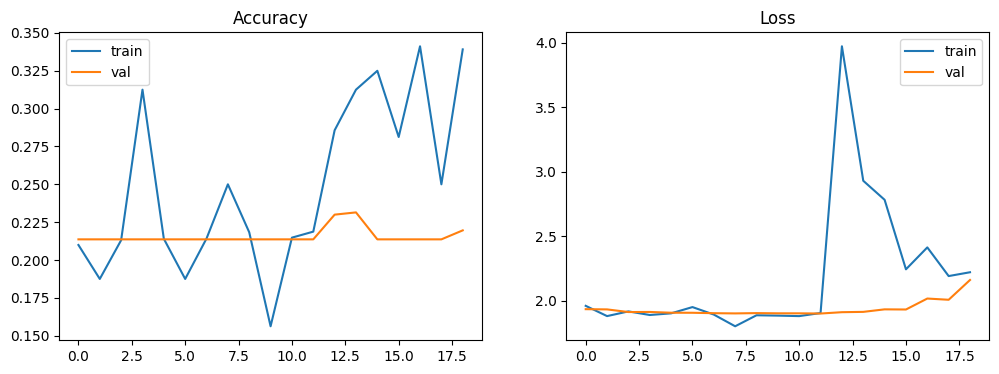

In [8]:
import matplotlib.pyplot as plt
acc = history1.history.get('accuracy',[]) + history2.history.get('accuracy',[])
val_acc = history1.history.get('val_accuracy',[]) + history2.history.get('val_accuracy',[])
loss = history1.history.get('loss',[]) + history2.history.get('loss',[])
val_loss = history1.history.get('val_loss',[]) + history2.history.get('val_loss',[])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(acc); plt.plot(val_acc); plt.title('Accuracy'); plt.legend(['train','val'])
plt.subplot(1,2,2); plt.plot(loss); plt.plot(val_loss); plt.title('Loss'); plt.legend(['train','val'])
plt.show()


43/43 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step
                            precision    recall  f1-score   support

                 Cardboard       0.00      0.00      0.00       173
Food,Organics,BIO - Wastes       0.00      0.00      0.00       170
                     Glass       0.00      0.00      0.00       184
                     Metal       0.25      0.31      0.28       240
                     Paper       0.00      0.00      0.00       223
                   Plastic       0.22      0.79      0.34       288
             Textile Trash       0.00      0.00      0.00        70

                  accuracy                           0.22      1348
                 macro avg       0.07      0.16      0.09      1348
              weighted avg       0.09      0.22      0.12      1348



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


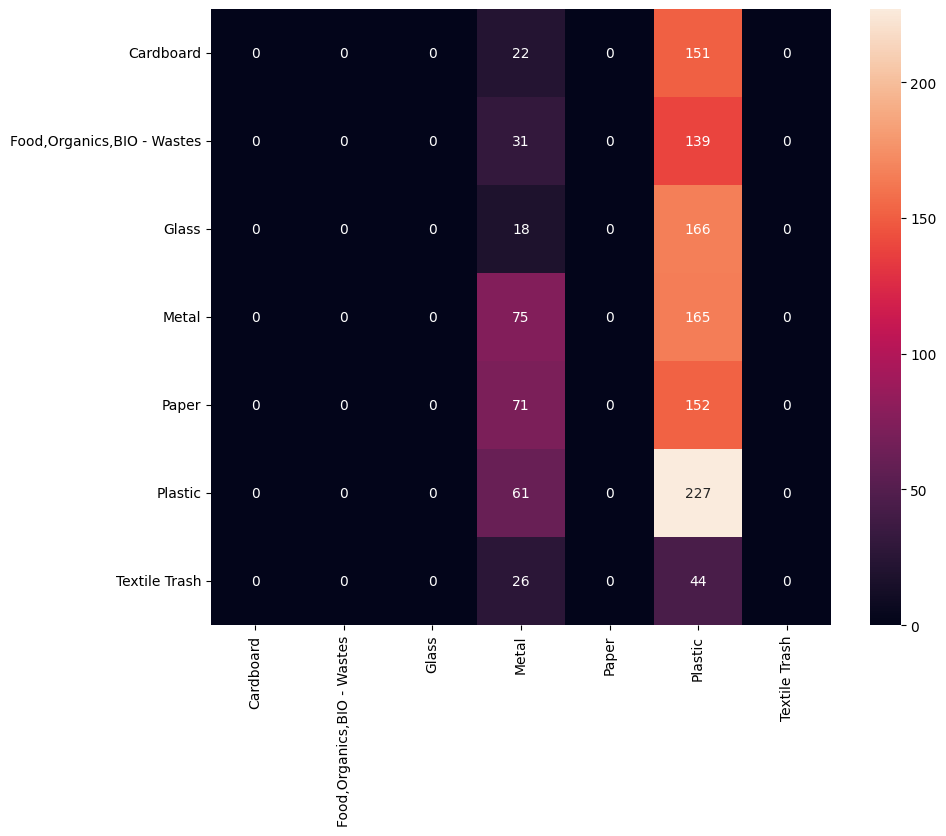

In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
val_gen.reset()
preds = model.predict(val_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes
labels = list(train_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels))
cm = confusion_matrix(y_true, y_pred)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8)); sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels); plt.show()


In [10]:
model.save("/kaggle/working/waste_saved_model")
model.save("/kaggle/working/waste_model.h5")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=/kaggle/working/waste_saved_model.

In [ ]:
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_saved_model("/kaggle/working/waste_saved_model")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()
open('/kaggle/working/waste_model_float16.tflite','wb').write(tflite_model)
print("Saved float16 tflite")


In [ ]:
def representative_gen():
    import numpy as np
    gen = train_gen
    gen.reset()
    for i in range(200):
        x,_ = next(gen)
        yield [x.astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_saved_model("/kaggle/working/waste_saved_model")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8
tflite_int8 = converter.convert()
open('/kaggle/working/waste_model_int8.tflite','wb').write(tflite_int8)
print("Saved int8 tflite")


In [ ]:
import time, numpy as np
interpreter = tf.lite.Interpreter(model_path='/kaggle/working/waste_model_float16.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details(); output_details = interpreter.get_output_details()

# prepare single sample
import cv2
sample = cv2.imread(list(val_gen.filepaths[:1])[0])
sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)
sample = cv2.resize(sample, (224,224)) / 255.0
sample = np.expand_dims(sample.astype(np.float32), axis=0)

# run 50 warmups then avg
for _ in range(10):
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()

times = []
for _ in range(50):
    t0 = time.time()
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    times.append(time.time()-t0)
print("Avg latency (float16 tflite) ms:", np.mean(times)*1000)


In [ ]:
from tensorflow.keras.applications import MobileNetV2
student_base = MobileNetV2(include_top=False, input_shape=(224,224,3), weights='imagenet', pooling='avg')
student_base.trainable = False
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
x = student_base.output
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(num_classes, activation='softmax')(x)
student = Model(student_base.input, out)
student.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
student.fit(train_gen, validation_data=val_gen, epochs=8)
student.save('/kaggle/working/student_mobilenetv2.h5')
# convert student to tflite similarly


In [ ]:
# pi_infer.py (run on Pi with tflite_runtime installed)
import cv2, numpy as np, time
from tflite_runtime.interpreter import Interpreter

model_path = 'waste_model_int8.tflite'
labels = ['cardboard','food_organic','glass','metal','paper','plastic','textile']  # adjust order to match your class indices

interpreter = Interpreter(model_path)
interpreter.allocate_tensors()
input_idx = interpreter.get_input_details()[0]['index']
out_idx = interpreter.get_output_details()[0]['index']

cap = cv2.VideoCapture(0)  # Pi camera via v4l2 or USB camera
while True:
    ret, frame = cap.read()
    if not ret: break
    img = cv2.resize(frame, (224,224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    inp = np.expand_dims(img.astype(np.uint8), axis=0)  # if INT8 model use uint8 inputs
    interpreter.set_tensor(input_idx, inp)
    t0 = time.time()
    interpreter.invoke()
    dt = time.time()-t0
    out = interpreter.get_tensor(out_idx)[0]
    idx = out.argmax()
    conf = out[idx] / (255.0 if out.dtype == np.uint8 else 1.0)
    cv2.putText(frame, f"{labels[idx]} {conf:.2f} {dt*1000:.0f}ms", (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0),2)
    cv2.imshow('frame', frame)
    if cv2.waitKey(1)==27: break
cap.release()
cv2.destroyAllWindows()
